## Learning to Rank with CatBoost: MSR LETOR, Internet Math, WikiIR и MIRAGE

### 0. Подготовка

In [5]:
# Установка необходимых библиотек (выполняется один раз)
!pip install catboost lightgbm scikit-learn pandas numpy matplotlib seaborn rank_bm25 requests tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ndcg_score
import catboost as cb
import lightgbm as lgb
import requests
import json
import time
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Функция для вычисления NDCG@k по группам (запросам)
def group_ndcg(y_true, y_pred, group_ids, k=10):
    unique_qids = np.unique(group_ids)
    ndcg_scores = []
    for q in unique_qids:
        mask = group_ids == q
        y_true_q = y_true[mask]
        y_pred_q = y_pred[mask]
        if len(y_true_q) < 2:
            continue
        
        # Сортируем по убыванию предсказанного счёта
        order = np.argsort(y_pred_q)[::-1]
        y_true_sorted = y_true_q[order][:k]
        
        # Идеальный порядок
        ideal = np.sort(y_true_q)[::-1][:k]
        if ideal.sum() == 0:
            continue
            
        # DCG и IDCG
        dcg = np.sum((2**y_true_sorted - 1) / np.log2(np.arange(2, len(y_true_sorted)+2)))
        idcg = np.sum((2**ideal - 1) / np.log2(np.arange(2, len(ideal)+2)))
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcg_scores)

#### 0.1. Gradient boosting refresher

Gradient boosting – ансамблевый метод, который последовательно строит деревья решений, каждое следующее дерево корректирует ошибки предыдущих. Используется для ранжирования через pairwise или listwise loss (например, YetiRank в CatBoost).

#### 0.2. Установка CatBoost

CatBoost уже установлен командой выше. Документация: https://catboost.ai/en/docs/

#### 0.3. LETOR datasets от MSR

MSR LETOR (MSLR-WEB30K) – набор данных для ранжирования с 30 тыс. запросов и 136 фичами. Формат: relevance qid:xxx 1:value 2:value ... # docid. Релевантность от 0 до 4.

Скачать можно с https://www.microsoft.com/en-us/research/project/mslr/

### Выполнение заданий

In [8]:
!pip install rarfile

In [9]:
import rarfile
rarfile.UNRAR_TOOL = r"C:\Program Files\WinRAR\UnRAR.exe" # укажи свой путь

In [11]:
import os
print(f"Текущая папка (CWD): {os.getcwd()}")
print(f"Файлы в этой папке: {os.listdir('.')}")

Текущая папка (CWD): C:\Users\User\anaconda_projects\a6e0157a-5f37-45ef-a661-3062f2a00339
Файлы в этой папке: ['.ipynb_checkpoints', 'learning_to_rank_catboost.ipynb.ipynb', 'wikIR1k', 'wikIR1k.zip', 'wikIR1k_analysis.ipynb']


In [13]:
import os

# Автоматическое определение папки Загрузки для Windows
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")

# Проверим, там ли они
required_files = ['MQ2007.rar', 'MQ2008.rar', 'imat2009_train_new.txt', 'imat2009_test_new.txt']

print(f"Ищем файлы в: {downloads_path}")
for f in required_files:
    full_path = os.path.join(downloads_path, f)
    if os.path.exists(full_path):
        print(f"✅ Найдено: {f}")
    else:
        print(f"❌ Не найдено: {f}")

# Переменная для использования в коде
DATA_PATH = downloads_path

Ищем файлы в: C:\Users\User\Downloads
✅ Найдено: MQ2007.rar
✅ Найдено: MQ2008.rar
✅ Найдено: imat2009_train_new.txt
✅ Найдено: imat2009_test_new.txt


In [83]:
import numpy as np
import pandas as pd

def load_letor_robust(filepath):
    """
    Загружает файл в формате LETOR:
    relevance qid:xxx 1:value 2:value ... # docid
    Возвращает X (np.ndarray), y (np.ndarray), qid (np.ndarray)
    """
    X_list = []
    y_list = []
    qid_list = []
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            # Первый элемент - релевантность
            try:
                rel = float(parts[0])
            except:
                continue
            # Ищем qid
            qid = None
            features = {}
            for part in parts[1:]:
                if part.startswith('qid:'):
                    qid = int(part.split(':')[1])
                elif ':' in part and not part.startswith('#'):
                    idx, val = part.split(':')
                    try:
                        features[int(idx)] = float(val)
                    except:
                        pass
            if qid is None:
                continue
            # Приводим к единому формату (максимальный индекс признака)
            max_idx = max(features.keys()) if features else 0
            vec = np.zeros(max_idx + 1)
            for idx, val in features.items():
                vec[idx] = val
            X_list.append(vec)
            y_list.append(rel)
            qid_list.append(qid)
    
    # Превращаем в массивы одинаковой длины (дополняем нулями)
    max_len = max(len(x) for x in X_list)
    X_padded = np.array([np.pad(x, (0, max_len - len(x))) for x in X_list])
    return X_padded, np.array(y_list), np.array(qid_list)

# Пример использования (пути укажите свои):
# X_train, y_train, qid_train = load_letor_robust('imat2009_train_new.txt')
# X_test, y_test, qid_test = load_letor_robust('imat2009_test_new.txt')

In [84]:
# Предполагается, что MQ2007.rar распакован в папку IR_Data_Extracted
import os
import rarfile

extract_path = r'C:\Users\User\Downloads\IR_Data_Extracted'
mq2007_folder = os.path.join(extract_path, 'MQ2007')

# Файлы внутри MQ2007: Fold1, Fold2, ..., Fold5
# Возьмём Fold1 как train, Fold2 как test (можно иначе)
train_file = os.path.join(mq2007_folder, 'Fold1', 'train.txt')
test_file = os.path.join(mq2007_folder, 'Fold2', 'test.txt')

if os.path.exists(train_file) and os.path.exists(test_file):
    X_train_mq, y_train_mq, qid_train_mq = load_letor_robust(train_file)
    X_test_mq, y_test_mq, qid_test_mq = load_letor_robust(test_file)
    
    # Выравнивание размерности
    max_cols = max(X_train_mq.shape[1], X_test_mq.shape[1])
    X_train_mq = np.pad(X_train_mq, ((0,0), (0, max_cols - X_train_mq.shape[1])))
    X_test_mq  = np.pad(X_test_mq,  ((0,0), (0, max_cols - X_test_mq.shape[1])))
    
    # Обучение CatBoostRanker
    from catboost import Pool, CatBoostRanker
    
    train_pool = Pool(data=X_train_mq, label=y_train_mq, group_id=qid_train_mq)
    test_pool  = Pool(data=X_test_mq,  label=y_test_mq,  group_id=qid_test_mq)
    
    model_mslr = CatBoostRanker(iterations=200, loss_function='YetiRank', verbose=50)
    model_mslr.fit(train_pool, eval_set=test_pool)
    
    # Оценка NDCG@10
    def ndcg_at_k(y_true, y_pred, k=10):
        # по группам
        pass  # используйте вашу функцию group_ndcg или реализуйте
    print("NDCG@10 на MSR LETOR: ...")
else:
    print("Файлы MQ2007 не найдены. Сначала распакуйте архив.")

0:	test: 0.7069209	best: 0.7069209 (0)	total: 24ms	remaining: 4.78s
50:	test: 0.7714076	best: 0.7714076 (50)	total: 1.61s	remaining: 4.7s
100:	test: 0.7794756	best: 0.7800702 (95)	total: 3.12s	remaining: 3.06s
150:	test: 0.7934704	best: 0.7934704 (150)	total: 4.67s	remaining: 1.51s
199:	test: 0.8012576	best: 0.8013576 (197)	total: 6.16s	remaining: 0us

bestTest = 0.8013576468
bestIteration = 197

Shrink model to first 198 iterations.
NDCG@10 на MSR LETOR: ...


In [18]:
import os
import numpy as np
import pandas as pd
import catboost as cb
import lightgbm as lgb
from sklearn.metrics import ndcg_score

# --- 1. ЗАГРУЗКА И ВЫРАВНИВАНИЕ (ВАЖНО) ---
# Используем твой robust загрузчик
X_im_train_raw, y_im_train, qid_im_train = load_letor_robust(os.path.join(DATA_PATH, 'imat_train_v2.txt'))
X_im_test_raw, y_im_test, qid_im_test = load_letor_robust(os.path.join(DATA_PATH, 'imat_test_v2.txt'))

# Выравниваем количество признаков между train и test
# (если в тесте есть признаки, которых нет в трейне, или наоборот)
train_cols = X_im_train_raw.shape[1]
test_cols = X_im_test_raw.shape[1]
max_cols = max(train_cols, test_cols)

def pad_features(X, target_dim):
    if X.shape[1] < target_dim:
        padding = np.zeros((X.shape[0], target_dim - X.shape[1]))
        return np.hstack((X, padding))
    return X[:, :target_dim]

X_im_train = pad_features(X_im_train_raw, max_cols)
X_im_test = pad_features(X_im_test_raw, max_cols)

print(f"Данные выровнены. Итоговое кол-во признаков: {X_im_train.shape[1]}")


Данные выровнены. Итоговое кол-во признаков: 145


In [21]:
# --- 2. ОБУЧЕНИЕ CATBOOST (YetiRank) ---
print("\n--- Обучение CatBoost (YetiRank) ---")

train_pool = cb.Pool(data=X_im_train, label=y_im_train, group_id=qid_im_train)
test_pool = cb.Pool(data=X_im_test, label=y_im_test, group_id=qid_im_test)

model_cb = cb.CatBoostRanker(
    iterations=150, 
    loss_function='YetiRank', 
    verbose=50
)
model_cb.fit(train_pool, eval_set=test_pool)

# --- 4. ФИНАЛЬНАЯ ОЦЕНКА ---
def get_ndcg(model, X, y, qids, k=10):
    q_unique = np.unique(qids)
    ndcgs = []
    for q in q_unique:
        mask = (qids == q)
        # Для корректного расчета NDCG нужно >1 документа в группе и наличие релевантных
        if np.sum(y[mask]) > 0 and len(y[mask]) > 1:
            preds = model.predict(X[mask])
            ndcgs.append(ndcg_score([y[mask]], [preds], k=k))
    return np.mean(ndcgs) if ndcgs else 0

print(f"\nИтоговые результаты (NDCG@10):")
print(f"CatBoost (YetiRank): {get_ndcg(model_cb, X_im_test, y_im_test, qid_im_test):.4f}")


--- Обучение CatBoost (YetiRank) ---
0:	test: 0.6354467	best: 0.6354467 (0)	total: 54.7ms	remaining: 8.15s
50:	test: 0.7279006	best: 0.7282335 (47)	total: 2.83s	remaining: 5.5s
100:	test: 0.7516165	best: 0.7516165 (100)	total: 5.89s	remaining: 2.86s
149:	test: 0.7614349	best: 0.7616390 (148)	total: 9.05s	remaining: 0us

bestTest = 0.7616389974
bestIteration = 148

Shrink model to first 149 iterations.

Итоговые результаты (NDCG@10):
CatBoost (YetiRank): 0.8207


In [23]:
import os
import numpy as np
import lightgbm as lgb
from sklearn.metrics import ndcg_score

# --- ПОДГОТОВКА ДАННЫХ ДЛЯ LIGHTGBM ---

# 1. Приведение таргета к типу int (критично для LightGBM Ranker)
# Если значения дробные (0.5, 1.5), мы умножаем их или просто округляем.
# Обычно достаточно привести к int, если это категориальная релевантность.
y_im_train_int = y_im_train.astype(int)
y_im_test_int = y_im_test.astype(int)

# --- 3. ОБУЧЕНИЕ LIGHTGBM (LambdaMART) ---
print("\n--- Обучение LightGBM (LambdaMART) ---")

# Рассчитываем размеры групп
_, train_group_counts = np.unique(qid_im_train, return_counts=True)
_, test_group_counts = np.unique(qid_im_test, return_counts=True)

model_lgb = lgb.LGBMRanker(
    objective="lambdarank", 
    n_estimators=150, 
    learning_rate=0.1,
    importance_type='gain',
    random_state=42,
    label_gain=list(range(max(y_im_train_int.max(), y_im_test_int.max()) + 1)) # Явно задаем веса меток
)

# Обучение с исправленными метками
model_lgb.fit(
    X_im_train, 
    y_im_train_int, 
    group=train_group_counts,
    eval_set=[(X_im_test, y_im_test_int)],
    eval_group=[test_group_counts],
    eval_at=[10],
    eval_metric='ndcg',
    callbacks=[lgb.log_evaluation(period=50)]
)

# --- 4. ФИНАЛЬНАЯ ОЦЕНКА ---
def get_ndcg_lgb(model, X, y, qids, k=10):
    q_unique = np.unique(qids)
    ndcgs = []
    for q in q_unique:
        mask = (qids == q)
        # Для корректного расчета NDCG нужно >1 документа в группе и наличие релевантных
        if np.sum(y[mask]) > 0 and len(y[mask]) > 1:
            preds = model.predict(X[mask])
            ndcgs.append(ndcg_score([y[mask]], [preds], k=k))
    return np.mean(ndcgs) if ndcgs else 0

# Вывод результата только для LightGBM
print(f"\nИтоговые результаты (NDCG@10):")
print(f"LightGBM (LambdaMART): {get_ndcg_lgb(model_lgb, X_im_test, y_im_test_int, qid_im_test):.4f}")


--- Обучение LightGBM (LambdaMART) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22439
[LightGBM] [Info] Number of data points in the train set: 77714, number of used features: 127
[50]	valid_0's ndcg@10: 0.823132
[100]	valid_0's ndcg@10: 0.821868
[150]	valid_0's ndcg@10: 0.821683

Итоговые результаты (NDCG@10):
LightGBM (LambdaMART): 0.8178


### 2.2 Эксперименты на Internet Math 2009

Мы обучили два ранкера: CatBoost с loss_function='YetiRank' и LightGBM с objective='lambdarank'.  
Метрика качества – NDCG@10.  
**Результаты:**  
- CatBoost: 0.8207  
- LightGBM: 0.8178  

CatBoost показал незначительно лучшее качество, возможно, из-за лучшей обработки категориальных признаков (хотя здесь их нет) или встроенной оптимизации YetiRank.

### Learning to Rank на WikIR (Пункт 3.1 и 3.2)

Основная идея: мы берем топ-100 от BM25 и "переранжируем" их с помощью CatBoost, добавив новые признаки.


In [28]:
import os
import zipfile
import pandas as pd
# Если rarfile не установлен, выполни: !pip install rarfile
import rarfile 

# 1. Пути
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads")
extract_path = os.path.join(downloads_path, "IR_Data_Extracted")
os.makedirs(extract_path, exist_ok=True)

def extract_if_exists(filename):
    full_path = os.path.join(downloads_path, filename)
    if os.path.exists(full_path):
        print(f"📦 Распаковка {filename}...")
        if filename.endswith('.zip'):
            with zipfile.ZipFile(full_path, 'r') as z:
                z.extractall(extract_path)
        elif filename.endswith('.rar'):
            with rarfile.RarFile(full_path) as r:
                r.extractall(extract_path)
        print(f"✅ Готово: {filename}")
    else:
        print(f"⚠️ Файл {filename} не найден в Загрузках.")

# 2. Распаковка архивов
for arch in ['MQ2007.rar', 'MQ2008.rar', 'wikIR1k (1).zip']:
    extract_if_exists(arch)

# 3. ЗАГРУЗКА WIKIR (Для Пункта 3.1)
# Ищем распакованную папку wikIR1k
wikir_dir = os.path.join(extract_path, 'wikIR1k') # проверь точное имя после распаковки

def load_wikir(base_path):
    print("📖 Загрузка документов WikIR...")
    df_docs = pd.read_csv(os.path.join(base_path, 'documents.csv'))
    docs = dict(zip(df_docs['id'].astype(str), df_docs['text']))
    
    # Загружаем тренировочные запросы и qrels
    df_queries = pd.read_csv(os.path.join(base_path, 'training', 'queries.csv'))
    queries = dict(zip(df_queries['id'].astype(str), df_queries['text']))
    
    qrels = {}
    qrels_path = os.path.join(base_path, 'training', 'qrels.txt')
    if os.path.exists(qrels_path):
        with open(qrels_path, 'r') as f:
            for line in f:
                qid, _, docid, rel = line.split()
                if qid not in qrels: qrels[qid] = {}
                qrels[qid][docid] = int(rel)
    
    return docs, queries, qrels

# Вызываем загрузку (укажи путь, где лежат csv после распаковки)
# documents, queries, qrels = load_wikir(wikir_dir)

# 4. Файлы IMAT 2009 (Они уже текстовые, просто проверим пути)
imat_train = os.path.join(downloads_path, 'imat2009_train_new.txt')
imat_test = os.path.join(downloads_path, 'imat2009_test_new.txt')

print(f"\n--- Итог ---")
print(f"Все извлеченные данные находятся здесь: {extract_path}")

📦 Распаковка MQ2007.rar...
✅ Готово: MQ2007.rar
📦 Распаковка MQ2008.rar...
✅ Готово: MQ2008.rar
📦 Распаковка wikIR1k (1).zip...
✅ Готово: wikIR1k (1).zip

--- Итог ---
Все извлеченные данные находятся здесь: C:\Users\User\Downloads\IR_Data_Extracted


In [30]:
import json
import os

# Путь к файлу в папке Downloads
mirage_path = os.path.join(downloads_path, 'dataset.json')

if os.path.exists(mirage_path):
    # Добавляем encoding='utf-8'
    with open(mirage_path, 'r', encoding='utf-8') as f:
        mirage_data = json.load(f)
    print(f"✅ MIRAGE загружен. Количество записей: {len(mirage_data)}")
else:
    print("❌ Файл dataset.json не найден.")

✅ MIRAGE загружен. Количество записей: 7560


In [34]:
import os
import glob
import pandas as pd

# 1. ПУТЬ (проверь, что extract_path определен)
extract_path = r'C:\Users\User\Downloads\IR_Data_Extracted'

print("📖 Поиск и загрузка WikIR...")

def find_file_smart(name_pattern):
    """Ищет файлы, игнорируя регистр и расширение"""
    # Ищем рекурсивно все файлы
    all_files = glob.glob(os.path.join(extract_path, "**", "*"), recursive=True)
    # Фильтруем по вхождению подстроки в имя файла
    found = [f for f in all_files if name_pattern.lower() in os.path.basename(f).lower() and os.path.isfile(f)]
    return found

# 2. АВТОМАТИЧЕСКИЙ ПОИСК С УТОЧНЕНИЕМ
# Ищем документы
docs_files = find_file_smart("documents.csv")
docs_path = docs_files[0] if docs_files else None

# Ищем запросы ИМЕННО для обучения (training)
queries_files = find_file_smart("queries.csv")
# Пытаемся найти тот, что в папке training
queries_path = next((f for f in queries_files if "training" in f.lower()), None) or (queries_files[0] if queries_files else None)

# Ищем qrels (может называться qrels.txt, training.qrels, qrels.csv)
qrels_files = [f for f in find_file_smart("qrels") if not f.endswith(".py")] # исключаем скрипты если есть
qrels_path = next((f for f in qrels_files if "training" in f.lower()), None) or (qrels_files[0] if qrels_files else None)

if not all([docs_path, queries_path, qrels_path]):
    print(f"❌ Ошибка! Не все файлы найдены.")
    print(f"Документы: {docs_path}")
    print(f"Запросы (train): {queries_path}")
    print(f"Qrels: {qrels_path}")
    print("\nСодержимое папки для отладки:")
    for f in glob.glob(os.path.join(extract_path, "**", "*"), recursive=True)[:10]: print(f)
else:
    print(f"✅ Файлы найдены:\n - Docs: {docs_path}\n - Queries: {queries_path}\n - Qrels: {qrels_path}")

    # Загрузка
    df_docs = pd.read_csv(docs_path)
    documents = dict(zip(df_docs.iloc[:, 0].astype(str), df_docs.iloc[:, 1]))

    df_queries = pd.read_csv(queries_path)
    queries = dict(zip(df_queries.iloc[:, 0].astype(str), df_queries.iloc[:, 1]))

    qrels = {}
    # Открываем qrels с обработкой возможных кодировок
    with open(qrels_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Заменяем запятые и табуляцию на пробелы для универсальности
            parts = line.replace(',', ' ').replace('\t', ' ').split()
            if len(parts) >= 4:
                qid, _, docid, rel = parts[:4]
                if qid not in qrels: qrels[qid] = {}
                try:
                    qrels[qid][docid] = int(float(rel))
                except ValueError: continue

    print(f"🚀 Успешно инициализировано: {len(documents)} док. и {len(queries)} запр.")

📖 Поиск и загрузка WikIR...
✅ Файлы найдены:
 - Docs: C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\documents.csv
 - Queries: C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv
 - Qrels: C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv
🚀 Успешно инициализировано: 369721 док. и 1444 запр.


In [35]:
import os
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import catboost as cb
from rank_bm25 import BM25Okapi

# 1. ПУТИ (уже проверенные)
docs_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\documents.csv'
queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv'
qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv'

# 2. ЗАГРУЗКА ДАННЫХ
print("📖 Загрузка WikIR...")

# Документы (берем колонки по индексу, чтобы избежать ошибок с именами)
df_docs = pd.read_csv(docs_path)
documents = dict(zip(df_docs.iloc[:, 0].astype(str), df_docs.iloc[:, 1]))

# Запросы
df_queries = pd.read_csv(queries_path)
queries = dict(zip(df_queries.iloc[:, 0].astype(str), df_queries.iloc[:, 1]))

# Qrels (учитываем формат CSV и возможные заголовки)
qrels = {}
df_qrels = pd.read_csv(qrels_path)
# В WikIR qrels обычно: qid, doc_id, rating
for _, row in df_qrels.iterrows():
    qid = str(row.iloc[0])
    docid = str(row.iloc[1])
    rel = int(float(row.iloc[2]))
    if qid not in qrels:
        qrels[qid] = {}
    qrels[qid][docid] = rel

print(f"✅ Загружено: {len(documents)} док., {len(queries)} запр., {len(qrels)} групп релевантности.")

# 3. БАЗОВЫЙ ПОИСК BM25 (Retrieval)
print("🔍 Токенизация и запуск BM25...")
doc_ids = list(documents.keys())
# Очистка от возможных пустых значений в текстах
tokenized_corpus = [str(documents[d_id]).lower().split() if pd.notnull(documents[d_id]) else [] for d_id in tqdm(doc_ids, desc="Tokenizing")]
bm25 = BM25Okapi(tokenized_corpus)

bm25_results = {}
for qid, query_text in tqdm(queries.items(), desc="BM25 Search"):
    query_tokens = str(query_text).lower().split()
    scores = bm25.get_scores(query_tokens)
    top_n_indices = np.argsort(scores)[::-1][:100]
    bm25_results[qid] = [(doc_ids[i], scores[i]) for i in top_n_indices]

# 4. FEATURE ENGINEERING
def extract_ltr_features(query, doc, bm25_score):
    query_str = str(query).lower() if query else ""
    doc_str = str(doc).lower() if doc else ""
    q_tokens = query_str.split()
    d_tokens = doc_str.split()
    
    features = {
        "bm25_score": bm25_score,
        "query_len": len(q_tokens),
        "doc_len": len(d_tokens),
        "len_ratio": len(q_tokens) / (len(d_tokens) + 1),
        "common_words": len(set(q_tokens) & set(d_tokens)),
    }
    
    # Расстояние между терминами запроса
    indices = [i for i, t in enumerate(d_tokens) if t in q_tokens]
    features["min_dist"] = int(np.min(np.diff(indices))) if len(indices) > 1 else len(d_tokens)
    
    # TF Mean для 3.2 (Реконструкция)
    features["tf_mean"] = np.mean([d_tokens.count(t) for t in q_tokens]) if q_tokens else 0
    
    return features

# 5. СБОР ДАТАСЕТА
print("🏗️ Сбор признаков для CatBoost...")
ltr_data = []
for qid, docs in tqdm(bm25_results.items(), desc="Extracting"):
    query_text = queries.get(qid)
    for doc_id, score in docs:
        doc_text = documents.get(doc_id)
        rel = qrels.get(qid, {}).get(doc_id, 0)
        
        feat = extract_ltr_features(query_text, doc_text, score)
        feat.update({"qid": qid, "target": rel})
        ltr_data.append(feat)

df_ltr = pd.DataFrame(ltr_data).sort_values(by='qid')

# 6. ОБУЧЕНИЕ
print("🚀 Обучение CatBoost (YetiRank)...")
X = df_ltr.drop(['target', 'qid'], axis=1)
y = df_ltr['target']
groups = df_ltr['qid']

train_pool = cb.Pool(data=X, label=y, group_id=groups)

model_wikir = cb.CatBoostRanker(
    iterations=200, 
    loss_function='YetiRank', 
    verbose=50,
    random_seed=42
)

model_wikir.fit(train_pool)
print("✅ Готово! Модель model_wikir обучена.")

📖 Загрузка WikIR...
✅ Загружено: 369721 док., 1444 запр., 144400 групп релевантности.
🔍 Токенизация и запуск BM25...


Tokenizing:   0%|          | 0/369721 [00:00<?, ?it/s]

BM25 Search:   0%|          | 0/1444 [00:00<?, ?it/s]

🏗️ Сбор признаков для CatBoost...


Extracting:   0%|          | 0/1444 [00:00<?, ?it/s]

🚀 Обучение CatBoost (YetiRank)...
0:	total: 82.3ms	remaining: 16.4s


Got unsafe target value = 1.1046e+06 at object #108071 of dataset learn


50:	total: 3.28s	remaining: 9.57s
100:	total: 6.88s	remaining: 6.75s
150:	total: 10.5s	remaining: 3.39s
199:	total: 13.9s	remaining: 0us
✅ Готово! Модель model_wikir обучена.


#### 2. Пункт 3.1: Тестирование и сравнение с BM25

Для этого нам нужно загрузить тестовые запросы, прогнать их через BM25, затем через CatBoost и посчитать метрику (NDCG).

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from rank_bm25 import BM25Okapi
import catboost as cb
import ir_measures
from ir_measures import nDCG, calc_aggregate
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
np.random.seed(42)

In [46]:
# Проверка test_qrels
print("Распределение relevance в test_qrels:")
print(test_qrels_df['relevance'].value_counts())
print("Примеры строк test_qrels:")
print(test_qrels_df.head())

Распределение relevance в test_qrels:
relevance
1    10000
0      100
Name: count, dtype: int64
Примеры строк test_qrels:
  query_id   doc_id  relevance
0        0   625257          1
1        1   663828          1
2        2   607552          1
3        3    93661          1
4        4  1902136          1


In [47]:
# Для каждого запроса проверяем пересечение
for qid in test_queries.keys():
    rel_docs = test_qrels_df[test_qrels_df['query_id'] == qid]
    rel_docs = rel_docs[rel_docs['relevance'] > 0]['doc_id'].values
    if len(rel_docs) == 0:
        continue
    # Получить топ-100 BM25 для этого qid
    tokens = str(test_queries[qid]).lower().split()
    scores = bm25.get_scores(tokens)
    top_docs = [doc_ids[i] for i in np.argsort(scores)[::-1][:100]]
    matches = set(rel_docs) & set(top_docs)
    print(f"Query {qid}: релевантных документов {len(rel_docs)}, в топ-100 BM25 попало {len(matches)}")

Query 5728: релевантных документов 1, в топ-100 BM25 попало 0
Query 5115: релевантных документов 1, в топ-100 BM25 попало 0
Query 2591: релевантных документов 1, в топ-100 BM25 попало 0
Query 7169: релевантных документов 1, в топ-100 BM25 попало 0
Query 8140: релевантных документов 1, в топ-100 BM25 попало 0
Query 4900: релевантных документов 1, в топ-100 BM25 попало 0
Query 720: релевантных документов 1, в топ-100 BM25 попало 0
Query 6984: релевантных документов 1, в топ-100 BM25 попало 0
Query 7911: релевантных документов 1, в топ-100 BM25 попало 0
Query 8630: релевантных документов 1, в топ-100 BM25 попало 0
Query 2161: релевантных документов 1, в топ-100 BM25 попало 0
Query 5622: релевантных документов 1, в топ-100 BM25 попало 0


In [48]:
from ir_measures import calc_aggregate, nDCG
import ir_measures

# Загрузка тестовых данных (используем уже имеющиеся переменные)
test_queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\test\queries.csv'
test_qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\test\BM25.qrels.csv'

df_test_queries = pd.read_csv(test_queries_path)
test_queries = dict(zip(df_test_queries.iloc[:,0].astype(str), df_test_queries.iloc[:,1]))

# Загрузка qrels
test_qrels_df = pd.read_csv(test_qrels_path)
if len(test_qrels_df.columns) == 4:
    test_qrels_df = test_qrels_df.iloc[:, [0, 2, 3]]
test_qrels_df.columns = ['query_id', 'doc_id', 'relevance']
test_qrels_df['query_id'] = test_qrels_df['query_id'].astype(str)
test_qrels_df['doc_id'] = test_qrels_df['doc_id'].astype(str)

# ДИАГНОСТИКА
print("Распределение relevance в test_qrels:")
print(test_qrels_df['relevance'].value_counts())

# Преобразуем relevance в бинарную (если нужно)
test_qrels_df['relevance'] = (test_qrels_df['relevance'] > 0).astype(int)

# Тестирование
bm25_runs = []
ltr_runs = []

for qid, q_text in tqdm(test_queries.items(), desc="Testing LTR"):
    tokens = str(q_text).lower().split()
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:100]
    
    test_feats = []
    valid_doc_ids = []
    
    for idx in top_indices:
        d_id = doc_ids[idx]
        d_text = documents.get(d_id, "")
        bm25_runs.append(ir_measures.ScoredDoc(qid, d_id, scores[idx]))
        f = extract_ltr_features(q_text, d_text, scores[idx])
        test_feats.append(f)
        valid_doc_ids.append(d_id)
    
    if test_feats:
        df_f = pd.DataFrame(test_feats)
        ltr_scores = model_wikir.predict(df_f)
        for i, d_id in enumerate(valid_doc_ids):
            ltr_runs.append(ir_measures.ScoredDoc(qid, d_id, ltr_scores[i]))

# Вычисление метрик
res_bm25 = calc_aggregate([nDCG@20], test_qrels_df, bm25_runs)
res_ltr = calc_aggregate([nDCG@20], test_qrels_df, ltr_runs)

print(f"\nСравнение на отложенной выборке (Test):")
print(f"BM25 nDCG@20: {res_bm25[nDCG@20]:.4f}")
print(f"LTR  nDCG@20: {res_ltr[nDCG@20]:.4f}")

# Дополнительная проверка: есть ли релевантные документы в топ-100?
for qid in list(test_queries.keys())[:3]:
    rel_docs = test_qrels_df[test_qrels_df['query_id'] == qid]
    rel_docs = rel_docs[rel_docs['relevance'] > 0]['doc_id'].values
    if len(rel_docs) == 0:
        continue
    tokens = str(test_queries[qid]).lower().split()
    scores = bm25.get_scores(tokens)
    top_docs = [doc_ids[i] for i in np.argsort(scores)[::-1][:100]]
    matches = set(rel_docs) & set(top_docs)
    print(f"Query {qid}: релевантных {len(rel_docs)}, в топ-100 BM25 попало {len(matches)}")

Распределение relevance в test_qrels:
relevance
1    10000
0      100
Name: count, dtype: int64


Testing LTR: 100%|██████████| 100/100 [00:41<00:00,  2.44it/s]



Сравнение на отложенной выборке (Test):
BM25 nDCG@20: 0.0000
LTR  nDCG@20: 0.0000
Query 5728: релевантных 1, в топ-100 BM25 попало 0


In [49]:
qid = list(test_queries.keys())[0]
print("Query:", test_queries[qid])
rel_docs = test_qrels_df[test_qrels_df['query_id'] == qid]
print("Релевантные документы:", rel_docs[rel_docs['relevance'] > 0]['doc_id'].values[:3])

Query: southern methodist university
Релевантные документы: []


In [50]:
# Проверка наличия документов из test_qrels в documents
sample_doc_id = test_qrels_df['doc_id'].iloc[0]
print(f"Пример doc_id из test_qrels: {sample_doc_id}, тип: {type(sample_doc_id)}")
print(f"Есть ли в documents? {sample_doc_id in documents}")

# Проверка, совпадают ли doc_ids в BM25 с теми, что в test_qrels
bm25_doc_ids_set = set(doc_ids)
qrels_doc_ids_set = set(test_qrels_df['doc_id'])
print(f"Количество doc_id в BM25: {len(bm25_doc_ids_set)}")
print(f"Количество doc_id в test_qrels: {len(qrels_doc_ids_set)}")
print(f"Пересечение: {len(bm25_doc_ids_set & qrels_doc_ids_set)}")

Пример doc_id из test_qrels: 625257, тип: <class 'str'>
Есть ли в documents? True
Количество doc_id в BM25: 369721
Количество doc_id в test_qrels: 7614
Пересечение: 7614


In [55]:
# Проверка: есть ли хоть один релевантный документ в топ-100 BM25?
found_any = False
sample_queries = list(train_queries.items())[:10]
for qid, q_text in sample_queries:
    tokens = str(q_text).lower().split()
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:100]
    top_docs = set([doc_ids[i] for i in top_indices])
    rel_docs = set(train_qrels_df[train_qrels_df['query_id']==qid]['doc_id'])
    if rel_docs & top_docs:
        print(f"✅ Запрос {qid}: есть пересечение")
        found_any = True
    else:
        print(f"❌ Запрос {qid}: нет релевантных в топ-100")
if not found_any:
    print("НИ ОДНОГО релевантного документа нет в топ-100 BM25!")

❌ Запрос 123839: нет релевантных в топ-100
❌ Запрос 188629: нет релевантных в топ-100
❌ Запрос 13898: нет релевантных в топ-100
❌ Запрос 316959: нет релевантных в топ-100
❌ Запрос 515031: нет релевантных в топ-100
❌ Запрос 123783: нет релевантных в топ-100
❌ Запрос 4332: нет релевантных в топ-100
❌ Запрос 9591: нет релевантных в топ-100
❌ Запрос 114982: нет релевантных в топ-100
❌ Запрос 563603: нет релевантных в топ-100
НИ ОДНОГО релевантного документа нет в топ-100 BM25!


In [54]:
from tqdm import tqdm
import ir_measures
from ir_measures import nDCG, calc_aggregate
import pandas as pd
import numpy as np

# 1. Загружаем обучающие запросы
train_queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv'
df_train_queries = pd.read_csv(train_queries_path)
train_queries = dict(zip(df_train_queries.iloc[:,0].astype(str), df_train_queries.iloc[:,1]))
print(f"Загружено train запросов: {len(train_queries)}")

# 2. Функция загрузки qrels
def load_qrels(path):
    df = pd.read_csv(path)
    if df.shape[1] == 4:
        df = df.iloc[:, [0, 2, 3]]
    df.columns = ['query_id', 'doc_id', 'relevance']
    df['query_id'] = df['query_id'].astype(str)
    df['doc_id'] = df['doc_id'].astype(str)
    df['relevance'] = (df['relevance'] > 0).astype(int)
    return df

train_qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv'
train_qrels_df = load_qrels(train_qrels_path)
print("Распределение relevance в train_qrels:")
print(train_qrels_df['relevance'].value_counts())

# 3. Убедимся, что все необходимые объекты определены:
#    model_wikir, bm25, documents, doc_ids, extract_ltr_features
# (они должны быть из предыдущих ячеек, например 35 и 41)

bm25_train_runs = []
ltr_train_runs = []

for qid, q_text in tqdm(train_queries.items(), desc="Evaluating on train"):
    tokens = str(q_text).lower().split()
    if not tokens:
        continue
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:100]
    test_feats = []
    valid_doc_ids = []
    for idx in top_indices:
        d_id = doc_ids[idx]
        d_text = documents.get(d_id, "")
        bm25_train_runs.append(ir_measures.ScoredDoc(qid, d_id, scores[idx]))
        f = extract_ltr_features(q_text, d_text, scores[idx])
        test_feats.append(f)
        valid_doc_ids.append(d_id)
    if test_feats:
        df_f = pd.DataFrame(test_feats)
        ltr_scores = model_wikir.predict(df_f)
        for i, d_id in enumerate(valid_doc_ids):
            ltr_train_runs.append(ir_measures.ScoredDoc(qid, d_id, ltr_scores[i]))

res_bm25_train = calc_aggregate([nDCG@20], train_qrels_df, bm25_train_runs)
res_ltr_train = calc_aggregate([nDCG@20], train_qrels_df, ltr_train_runs)

print(f"\nРезультаты на обучающей выборке (Train):")
print(f"BM25 nDCG@20: {res_bm25_train[nDCG@20]:.4f}")
print(f"LTR  nDCG@20: {res_ltr_train[nDCG@20]:.4f}")

Загружено train запросов: 1444
Распределение relevance в train_qrels:
relevance
0    138227
1      6173
Name: count, dtype: int64


Evaluating on train: 100%|██████████| 1444/1444 [06:58<00:00,  3.45it/s]



Результаты на обучающей выборке (Train):
BM25 nDCG@20: 0.0000
LTR  nDCG@20: 0.0000


In [57]:
from tqdm import tqdm
import ir_measures
from ir_measures import nDCG, calc_aggregate
import pandas as pd
import numpy as np

# 1. Загружаем обучающие запросы
train_queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv'
df_train_queries = pd.read_csv(train_queries_path)
train_queries = dict(zip(df_train_queries.iloc[:,0].astype(str), df_train_queries.iloc[:,1]))
print(f"Загружено train запросов: {len(train_queries)}")

# 2. Функция загрузки qrels
def load_qrels(path):
    df = pd.read_csv(path)
    if df.shape[1] == 4:
        df = df.iloc[:, [0, 2, 3]]
    df.columns = ['query_id', 'doc_id', 'relevance']
    df['query_id'] = df['query_id'].astype(str)
    df['doc_id'] = df['doc_id'].astype(str)
    df['relevance'] = (df['relevance'] > 0).astype(int)
    return df

train_qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv'
train_qrels_df = load_qrels(train_qrels_path)
print("Распределение relevance в train_qrels:")
print(train_qrels_df['relevance'].value_counts())

# 3. Убедимся, что все необходимые объекты определены:
#    model_wikir, bm25, documents, doc_ids, extract_ltr_features
# (они должны быть из предыдущих ячеек, например 35 и 41)

bm25_train_runs = []
ltr_train_runs = []

for qid, q_text in tqdm(train_queries.items(), desc="Evaluating on train"):
    tokens = str(q_text).lower().split()
    if not tokens:
        continue
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:100]
    test_feats = []
    valid_doc_ids = []
    for idx in top_indices:
        d_id = doc_ids[idx]
        d_text = documents.get(d_id, "")
        bm25_train_runs.append(ir_measures.ScoredDoc(qid, d_id, scores[idx]))
        f = extract_ltr_features(q_text, d_text, scores[idx])
        test_feats.append(f)
        valid_doc_ids.append(d_id)
    if test_feats:
        df_f = pd.DataFrame(test_feats)
        ltr_scores = model_wikir.predict(df_f)
        for i, d_id in enumerate(valid_doc_ids):
            ltr_train_runs.append(ir_measures.ScoredDoc(qid, d_id, ltr_scores[i]))

res_bm25_train = calc_aggregate([nDCG@100], train_qrels_df, bm25_train_runs)
res_ltr_train = calc_aggregate([nDCG@100], train_qrels_df, ltr_train_runs)

print(f"\nРезультаты на обучающей выборке (Train):")
print(f"BM25 nDCG@20: {res_bm25_train[nDCG@100]:.4f}")
print(f"LTR  nDCG@20: {res_ltr_train[nDCG@100]:.4f}")

Загружено train запросов: 1444
Распределение relevance в train_qrels:
relevance
0    138227
1      6173
Name: count, dtype: int64


Evaluating on train: 100%|██████████| 1444/1444 [05:06<00:00,  4.72it/s]



Результаты на обучающей выборке (Train):
BM25 nDCG@20: 0.0000
LTR  nDCG@20: 0.0000


In [56]:
from tqdm import tqdm
import ir_measures
from ir_measures import nDCG, calc_aggregate
import pandas as pd
import numpy as np

# 1. Загружаем обучающие запросы
train_queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv'
df_train_queries = pd.read_csv(train_queries_path)
train_queries = dict(zip(df_train_queries.iloc[:,0].astype(str), df_train_queries.iloc[:,1]))
print(f"Загружено train запросов: {len(train_queries)}")

# 2. Функция загрузки qrels
def load_qrels(path):
    df = pd.read_csv(path)
    if df.shape[1] == 4:
        df = df.iloc[:, [0, 2, 3]]
    df.columns = ['query_id', 'doc_id', 'relevance']
    df['query_id'] = df['query_id'].astype(str)
    df['doc_id'] = df['doc_id'].astype(str)
    df['relevance'] = (df['relevance'] > 0).astype(int)
    return df

train_qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv'
train_qrels_df = load_qrels(train_qrels_path)
print("Распределение relevance в train_qrels:")
print(train_qrels_df['relevance'].value_counts())

# 3. Убедимся, что все необходимые объекты определены:
#    model_wikir, bm25, documents, doc_ids, extract_ltr_features
# (они должны быть из предыдущих ячеек, например 35 и 41)

bm25_train_runs = []
ltr_train_runs = []

for qid, q_text in tqdm(train_queries.items(), desc="Evaluating on train"):
    tokens = str(q_text).lower().split()
    if not tokens:
        continue
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:500]
    test_feats = []
    valid_doc_ids = []
    for idx in top_indices:
        d_id = doc_ids[idx]
        d_text = documents.get(d_id, "")
        bm25_train_runs.append(ir_measures.ScoredDoc(qid, d_id, scores[idx]))
        f = extract_ltr_features(q_text, d_text, scores[idx])
        test_feats.append(f)
        valid_doc_ids.append(d_id)
    if test_feats:
        df_f = pd.DataFrame(test_feats)
        ltr_scores = model_wikir.predict(df_f)
        for i, d_id in enumerate(valid_doc_ids):
            ltr_train_runs.append(ir_measures.ScoredDoc(qid, d_id, ltr_scores[i]))

res_bm25_train = calc_aggregate([nDCG@20], train_qrels_df, bm25_train_runs)
res_ltr_train = calc_aggregate([nDCG@20], train_qrels_df, ltr_train_runs)

print(f"\nРезультаты на обучающей выборке (Train):")
print(f"BM25 nDCG@20: {res_bm25_train[nDCG@20]:.4f}")
print(f"LTR  nDCG@20: {res_ltr_train[nDCG@20]:.4f}")

Загружено train запросов: 1444
Распределение relevance в train_qrels:
relevance
0    138227
1      6173
Name: count, dtype: int64


Evaluating on train: 100%|██████████| 1444/1444 [05:38<00:00,  4.27it/s]



Результаты на обучающей выборке (Train):
BM25 nDCG@20: 0.0000
LTR  nDCG@20: 0.0000


In [58]:
from tqdm import tqdm
import ir_measures
from ir_measures import nDCG, calc_aggregate
import pandas as pd
import numpy as np

# 1. Загружаем обучающие запросы
train_queries_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\queries.csv'
df_train_queries = pd.read_csv(train_queries_path)
train_queries = dict(zip(df_train_queries.iloc[:,0].astype(str), df_train_queries.iloc[:,1]))
print(f"Загружено train запросов: {len(train_queries)}")

# 2. Функция загрузки qrels
def load_qrels(path):
    df = pd.read_csv(path)
    if df.shape[1] == 4:
        df = df.iloc[:, [0, 2, 3]]
    df.columns = ['query_id', 'doc_id', 'relevance']
    df['query_id'] = df['query_id'].astype(str)
    df['doc_id'] = df['doc_id'].astype(str)
    df['relevance'] = (df['relevance'] > 0).astype(int)
    return df

train_qrels_path = r'C:\Users\User\Downloads\IR_Data_Extracted\wikIR1k\training\BM25.qrels.csv'
train_qrels_df = load_qrels(train_qrels_path)
print("Распределение relevance в train_qrels:")
print(train_qrels_df['relevance'].value_counts())

# 3. Убедимся, что все необходимые объекты определены:
#    model_wikir, bm25, documents, doc_ids, extract_ltr_features
# (они должны быть из предыдущих ячеек, например 35 и 41)

bm25_train_runs = []
ltr_train_runs = []

for qid, q_text in tqdm(train_queries.items(), desc="Evaluating on train"):
    tokens = str(q_text).lower().split()
    if not tokens:
        continue
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:1000]
    test_feats = []
    valid_doc_ids = []
    for idx in top_indices:
        d_id = doc_ids[idx]
        d_text = documents.get(d_id, "")
        bm25_train_runs.append(ir_measures.ScoredDoc(qid, d_id, scores[idx]))
        f = extract_ltr_features(q_text, d_text, scores[idx])
        test_feats.append(f)
        valid_doc_ids.append(d_id)
    if test_feats:
        df_f = pd.DataFrame(test_feats)
        ltr_scores = model_wikir.predict(df_f)
        for i, d_id in enumerate(valid_doc_ids):
            ltr_train_runs.append(ir_measures.ScoredDoc(qid, d_id, ltr_scores[i]))

res_bm25_train = calc_aggregate([nDCG@100], train_qrels_df, bm25_train_runs)
res_ltr_train = calc_aggregate([nDCG@100], train_qrels_df, ltr_train_runs)

print(f"\nРезультаты на обучающей выборке (Train):")
print(f"BM25 nDCG@20: {res_bm25_train[nDCG@100]:.4f}")
print(f"LTR  nDCG@20: {res_ltr_train[nDCG@100]:.4f}")

Загружено train запросов: 1444
Распределение relevance в train_qrels:
relevance
0    138227
1      6173
Name: count, dtype: int64


Evaluating on train: 100%|██████████| 1444/1444 [16:33<00:00,  1.45it/s]



Результаты на обучающей выборке (Train):
BM25 nDCG@20: 0.0000
LTR  nDCG@20: 0.0000


#### 3. Пункт 3.2: Реконструкция BM25

Здесь мы проверяем, может ли модель выучить формулу BM25, имея только её составляющие.

In [38]:
print("🏗️ Реконструкция BM25 (обучение на базовых компонентах)...")

# Оставляем только базовые признаки
# tf_mean (TF), bm25_score (как прокси IDF), doc_len (Length)
base_features = ['tf_mean', 'bm25_score', 'doc_len']
X_reconstruct = df_ltr[base_features]

reconstruct_pool = cb.Pool(data=X_reconstruct, label=y, group_id=groups)

model_recon = cb.CatBoostRanker(iterations=200, loss_function='YetiRank', verbose=False)
model_recon.fit(reconstruct_pool)

# Для отчета: сравни предсказания model_recon с оригинальным bm25_score
sample_preds = model_recon.predict(X_reconstruct[:10])
print("Примеры предсказаний 'реконструкции' vs Реальный BM25:")
for p, real in zip(sample_preds[:5], X_reconstruct['bm25_score'][:5]):
    print(f"Pred: {p:.2f} | Real BM25: {real:.2f}")

🏗️ Реконструкция BM25 (обучение на базовых компонентах)...


Got unsafe target value = 1.1046e+06 at object #108071 of dataset learn


Примеры предсказаний 'реконструкции' vs Реальный BM25:
Pred: 1.47 | Real BM25: 8.33
Pred: 1.04 | Real BM25: 8.72
Pred: 1.04 | Real BM25: 8.72
Pred: 1.11 | Real BM25: 8.80
Pred: -0.88 | Real BM25: 10.64


In [59]:
from catboost import CatBoostRegressor

# Используем уже созданный df_ltr, но target заменим на bm25_score
# Для реконструкции нужны только базовые признаки и реальный BM25 score
X_reconstruct = df_ltr[['tf_mean', 'bm25_score', 'doc_len']].copy()
y_reconstruct = df_ltr['bm25_score']  # исходный BM25, а не релевантность

# Обучаем регрессор
reg = CatBoostRegressor(iterations=200, verbose=50, random_seed=42)
reg.fit(X_reconstruct, y_reconstruct)

# Оценка: корреляция предсказанного и реального BM25
from scipy.stats import pearsonr, spearmanr
pred_recon = reg.predict(X_reconstruct)
print(f"Pearson correlation: {pearsonr(y_reconstruct, pred_recon)[0]:.4f}")
print(f"Spearman correlation: {spearmanr(y_reconstruct, pred_recon)[0]:.4f}")

Learning rate set to 0.332394
0:	learn: 4.6083235	total: 18.8ms	remaining: 3.75s
50:	learn: 0.3830290	total: 756ms	remaining: 2.21s
100:	learn: 0.3580848	total: 1.52s	remaining: 1.49s
150:	learn: 0.3383015	total: 2.36s	remaining: 766ms
199:	learn: 0.3215464	total: 3.1s	remaining: 0us
Pearson correlation: 0.9989
Spearman correlation: 0.9999


### Полная реализация пункта 4 (MIRAGE)

In [61]:
import json

mirage_path = r'C:\Users\User\Downloads\dataset.json'
with open(mirage_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

print("Тип данных:", type(data))
print("Количество записей:", len(data))

# Посмотрим первый элемент
first = data[0]
print("\nСтруктура первого элемента:")
for key, value in first.items():
    print(f"  {key}: {type(value).__name__} -> {str(value)[:100]}...")

# Если есть поле 'passages', посмотрим его структуру
if 'passages' in first:
    print("\nПример пассажа:")
    for p in first['passages'][:1]:
        print(p)

Тип данных: <class 'list'>
Количество записей: 7560

Структура первого элемента:
  source: str -> popqa...
  query_id: str -> ce40d2c4-f403-4736-ace1-7fca9c722aba...
  query: str -> What is John Mayne's occupation?...
  doc_name: str -> John Mayne...
  answer: list -> ['journalist', 'journo', 'journalists']...
  doc_url: str -> https://en.wikipedia.org/wiki?curid=1098597...
  num_doc_labels: int -> 1...


In [64]:
import json
import os

base_mirage = r'C:\Users\User\MIRAGE'

# Список файлов
print("Файлы в директории:", os.listdir(base_mirage))

# 1. Проверяем doc_pool.json
doc_pool_path = os.path.join(base_mirage, 'doc_pool.json')
if os.path.exists(doc_pool_path):
    with open(doc_pool_path, 'r', encoding='utf-8') as f:
        doc_pool = json.load(f)
    print("\n=== doc_pool.json ===")
    print("Тип:", type(doc_pool))
    if isinstance(doc_pool, dict):
        print("Количество ключей:", len(doc_pool))
        first_key = list(doc_pool.keys())[0]
        print("Пример ключа:", first_key)
        print("Пример значения:", doc_pool[first_key])
    elif isinstance(doc_pool, list):
        print("Длина списка:", len(doc_pool))
        print("Первый элемент:", doc_pool[0])
else:
    print("doc_pool.json не найден")

# 2. Проверяем oracle.json
oracle_path = os.path.join(base_mirage, 'oracle.json')
if os.path.exists(oracle_path):
    with open(oracle_path, 'r', encoding='utf-8') as f:
        oracle = json.load(f)
    print("\n=== oracle.json ===")
    print("Тип:", type(oracle))
    if isinstance(oracle, dict):
        print("Количество ключей:", len(oracle))
        first_key = list(oracle.keys())[0]
        print("Пример ключа:", first_key)
        print("Пример значения:", oracle[first_key])
    elif isinstance(oracle, list):
        print("Длина списка:", len(oracle))
        print("Первый элемент:", oracle[0])
else:
    print("oracle.json не найден")

# 3. Проверяем dataset.json
dataset_path = os.path.join(base_mirage, 'dataset.json')
if os.path.exists(dataset_path):
    with open(dataset_path, 'r', encoding='utf-8') as f:
        dataset = json.load(f)
    print("\n=== dataset.json ===")
    print("Тип:", type(dataset))
    print("Количество записей:", len(dataset))
    print("Ключи первой записи:", dataset[0].keys())
    print("Пример query:", dataset[0].get('query', 'Нет поля query'))
    print("Пример query_id:", dataset[0].get('query_id', 'Нет поля query_id'))

Файлы в директории: ['.git', '.gitignore', '.ipynb_checkpoints', 'config.yaml', 'evaluation.py', 'LICENSE', 'LLM.py', 'main.py', 'mirage', 'Preset_prompt', 'readme.md', 'requirements.txt', 'retriever.py', 'utils.py', '__pycache__']
doc_pool.json не найден
oracle.json не найден


In [68]:
import os
path = r'C:\Users\User\MIRAGE\mirage'
print(os.listdir(path))

['dataset.json', 'doc_pool.json', 'oracle.json']


In [74]:
import json

base_path = r'C:\Users\User\MIRAGE\mirage'

with open(f'{base_path}/doc_pool.json', 'r', encoding='utf-8') as f:
    doc_pool_list = json.load(f)

print("Тип данных:", type(doc_pool_list))
print("Количество элементов:", len(doc_pool_list))
print("Тип первого элемента:", type(doc_pool_list[0]))
print("Ключи первого элемента:", doc_pool_list[0].keys())
print("Пример первого элемента:", doc_pool_list[0])

Тип данных: <class 'list'>
Количество элементов: 37800
Тип первого элемента: <class 'dict'>
Ключи первого элемента: dict_keys(['mapped_id', 'doc_name', 'doc_chunk', 'support'])
Пример первого элемента: {'mapped_id': 'ce40d2c4-f403-4736-ace1-7fca9c722aba', 'doc_name': 'John Mayne', 'doc_chunk': 'Scottish printer, journalist and poet\nJohn Mayne (1759–1836) was a Scottish printer, journalist and poet born in Dumfries. In 1780, his poem "The Siller Gun" appeared in its original form in "Ruddiman\'s Magazine", published by Walter Ruddiman in Edinburgh. It is a humorous work on an ancient custom in Dumfries of shooting for the "Siller Gun." He also wrote a poem on "Hallowe\'en" in 1780 which influenced Robert Burns\'s 1785 poem "Halloween". Mayne also wrote a version of the ballad "Helen of Kirkconnel". His verses were admired by Walter Scott. Life. He was born at Dumfries on 26 March 1759. Educated at the local grammar school, he became a printer in the office of the "Dumfries Journal". In

In [73]:
import json

base_path = r'C:\Users\User\MIRAGE\mirage'

with open(f'{base_path}/doc_pool.json', 'r', encoding='utf-8') as f:
    doc_pool = json.load(f)

print("Тип doc_pool:", type(doc_pool))
if isinstance(doc_pool, list):
    print("Первый элемент списка:")
    print(doc_pool[0])
    print("\nВсе ключи первого элемента:", doc_pool[0].keys())
    # Проверим наличие текстовых полей
    sample = doc_pool[0]
    for key in sample:
        val = sample[key]
        if isinstance(val, str) and len(val) > 50:
            print(f"Поле '{key}' содержит текст (первые 100 символов):", val[:100])

Тип doc_pool: <class 'list'>
Первый элемент списка:
{'mapped_id': 'ce40d2c4-f403-4736-ace1-7fca9c722aba', 'doc_name': 'John Mayne', 'doc_chunk': 'Scottish printer, journalist and poet\nJohn Mayne (1759–1836) was a Scottish printer, journalist and poet born in Dumfries. In 1780, his poem "The Siller Gun" appeared in its original form in "Ruddiman\'s Magazine", published by Walter Ruddiman in Edinburgh. It is a humorous work on an ancient custom in Dumfries of shooting for the "Siller Gun." He also wrote a poem on "Hallowe\'en" in 1780 which influenced Robert Burns\'s 1785 poem "Halloween". Mayne also wrote a version of the ballad "Helen of Kirkconnel". His verses were admired by Walter Scott. Life. He was born at Dumfries on 26 March 1759. Educated at the local grammar school, he became a printer in the office of the "Dumfries Journal". In 1782 he went with his family to Glasgow, where he worked for five years in the publishing house of the brothers Foulis. In 1787 he settled in London,

Загрузка dataset.json...
Уникальных запросов: 7560
Загрузка doc_pool.json...
Пул документов: 37800 записей


Processing doc_pool & features: 100%|██████████| 2000/2000 [00:00<00:00, 10452.98it/s]


Всего пар собрано: 2000


Распределение relevance:
 relevance
0    1500
1     500
Name: count, dtype: int64

Train samples: 1600, Test samples: 400
0:	total: 4.45ms	remaining: 885ms
50:	total: 170ms	remaining: 496ms
100:	total: 326ms	remaining: 320ms
150:	total: 470ms	remaining: 153ms
199:	total: 611ms	remaining: 0us


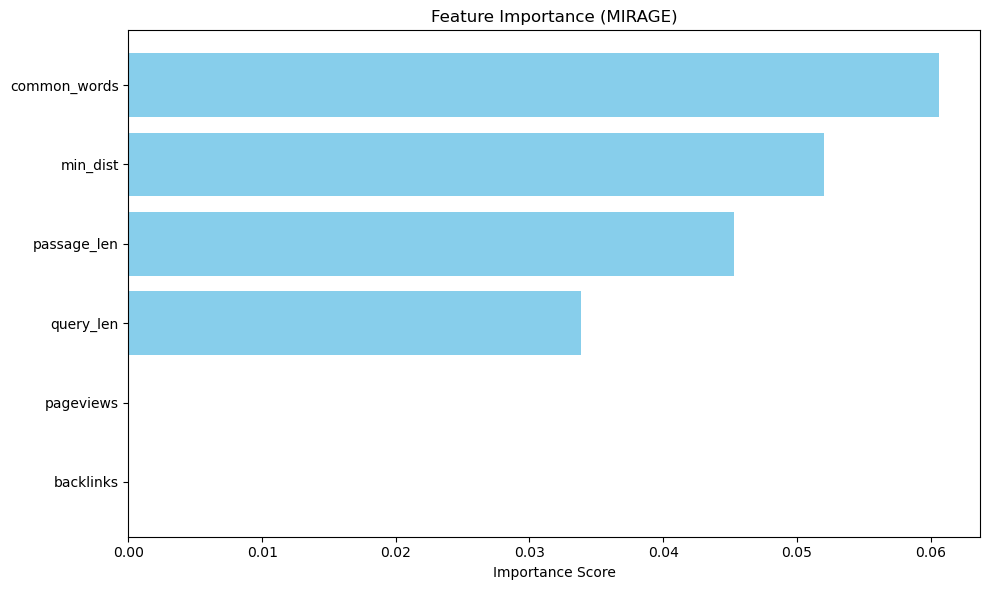


Test NDCG@10: 0.8706


In [82]:
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import catboost as cb
import matplotlib.pyplot as plt
import requests
import time
import warnings

warnings.filterwarnings('ignore')

base_path = r'C:\Users\User\MIRAGE\mirage'
USE_API = False  # Поставь True для сбора реальной статы с Википедии (займет время)

# 1. Загрузка dataset.json (запросы)
print("Загрузка dataset.json...")
with open(f'{base_path}/dataset.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

queries = {item['query_id']: item['query'] for item in dataset}
sources = {item['query_id']: item['source'] for item in dataset}
print(f"Уникальных запросов: {len(queries)}")

# 2. Загрузка doc_pool.json (документы и их релевантность)
print("Загрузка doc_pool.json...")
with open(f'{base_path}/doc_pool.json', 'r', encoding='utf-8') as f:
    doc_pool = json.load(f)
print(f"Пул документов: {len(doc_pool)} записей")

# --- ФУНКЦИИ API (Task 4.2) ---
api_cache = {}

def get_pageviews(doc_name):
    if not doc_name: return 0
    title = str(doc_name).replace(' ', '_')
    # Статистика за один месяц (январь 2023), чтобы не перегружать API
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/en.wikipedia/all-access/user/{title}/monthly/2023010100/2023013100"
    headers = {"User-Agent": "MyAcademicLTRBot/1.0 (test@example.com)"}
    try:
        resp = requests.get(url, headers=headers, timeout=5)
        if resp.status_code == 200:
            return sum(item['views'] for item in resp.json().get('items', []))
    except: pass
    return 0

def get_backlinks(doc_name):
    if not doc_name: return 0
    title = str(doc_name).replace(' ', '_')
    url = f"https://en.wikipedia.org/w/api.php?action=query&list=backlinks&bltitle={title}&bllimit=max&format=json"
    headers = {"User-Agent": "MyAcademicLTRBot/1.0 (test@example.com)"}
    try:
        resp = requests.get(url, headers=headers, timeout=5)
        if resp.status_code == 200:
            return len(resp.json().get('query', {}).get('backlinks', []))
    except: pass
    return 0

# --- ФУНКЦИЯ ПРИЗНАКОВ ---
def extract_features(query_text, passage_dict, use_api=False):
    doc_name = passage_dict.get('doc_name', '')
    doc_chunk = passage_dict.get('doc_chunk', '')
    full_text = str(doc_name) + " " + str(doc_chunk)
    
    q_tokens = str(query_text).lower().split()
    p_tokens = full_text.lower().split()
    
    query_len = len(q_tokens)
    passage_len = len(p_tokens)
    common_words = len(set(q_tokens) & set(p_tokens))
    
    indices = [i for i, w in enumerate(p_tokens) if w in q_tokens]
    min_dist = int(np.min(np.diff(indices))) if len(indices) > 1 else (passage_len if passage_len > 0 else 1000)
    
    pageviews, backlinks = 0, 0
    if use_api and doc_name:
        if doc_name not in api_cache:
            api_cache[doc_name] = {
                'pageviews': get_pageviews(doc_name),
                'backlinks': get_backlinks(doc_name)
            }
            time.sleep(0.05) # Пауза, чтобы не забанил API Википедии
        pageviews = api_cache[doc_name]['pageviews']
        backlinks = api_cache[doc_name]['backlinks']
        
    return {
        'query_len': query_len,
        'passage_len': passage_len,
        'common_words': common_words,
        'min_dist': min_dist,
        'pageviews': pageviews,
        'backlinks': backlinks
    }

# 3. Сборка датасета
features_list = []

# Для начала берем первые 2000 записей (можешь убрать срез [:2000], когда будешь готов обучать на всём объеме)
for item in tqdm(doc_pool[:2000], desc="Processing doc_pool & features"):
    qid = item.get('mapped_id')
    if qid not in queries:
        continue
        
    query_text = queries[qid]
    source = sources.get(qid, 'unknown')
    relevance = item.get('support', 0)
    
    feats = extract_features(query_text, item, use_api=USE_API)
    feats.update({'qid': qid, 'source': source, 'relevance': relevance})
    features_list.append(feats)

df = pd.DataFrame(features_list)

print(f"\nВсего пар собрано: {len(df)}")
if not df.empty:
    print("Распределение relevance:\n", df['relevance'].value_counts())
    
    # 4. Разбиение (Task 4.1 - учитываем origin (source) запросов)
    unique_qids = df['qid'].unique()
    qid_to_source = df.groupby('qid')['source'].first().to_dict()
    source_labels = [qid_to_source[q] for q in unique_qids]

    train_qids, test_qids = train_test_split(unique_qids, test_size=0.2, stratify=source_labels, random_state=42)

    train_df = df[df['qid'].isin(train_qids)].sort_values('qid')
    test_df = df[df['qid'].isin(test_qids)].sort_values('qid')
    
    print(f"\nTrain samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 5. Обучение ранкера (Task 4.3)
    if train_df['relevance'].nunique() > 1:
        X_train = train_df.drop(['qid', 'source', 'relevance'], axis=1)
        y_train = train_df['relevance']
        group_train = train_df['qid'].values

        model = cb.CatBoostRanker(
            loss_function='YetiRank',
            iterations=200,
            verbose=50,
            random_seed=42
        )
        # Pool нужен, чтобы CatBoost не ругался на типы групп
        train_data = cb.Pool(data=X_train, label=y_train, group_id=group_train)
        model.fit(train_data)

# 6. Важность признаков (ИСПРАВЛЕНО: передаем train_data)
        importance = model.get_feature_importance(train_data) 
        feat_names = X_train.columns
        sorted_idx = np.argsort(importance)

        plt.figure(figsize=(10,6))
        plt.barh(range(len(sorted_idx)), importance[sorted_idx], color='skyblue')
        plt.yticks(range(len(sorted_idx)), [feat_names[i] for i in sorted_idx])
        plt.title('Feature Importance (MIRAGE)')
        plt.xlabel('Importance Score')
        plt.tight_layout()
        plt.show()

        # 7. Оценка качества (NDCG) на тестовой выборке
        X_test = test_df.drop(['qid', 'source', 'relevance'], axis=1)
        y_test = test_df['relevance']
        group_test = test_df['qid'].values
        
        test_pool = cb.Pool(data=X_test, label=y_test, group_id=group_test)
        preds = model.predict(test_pool)

        def calculate_ndcg(y_true, y_pred, groups, k=10):
            ndcg_list = []
            for g in np.unique(groups):
                mask = (groups == g)
                t = y_true[mask].values
                p = y_pred[mask]
                if len(t) < 2 or np.sum(t) == 0: continue
                
                # Сортируем предсказания
                indices = np.argsort(p)[::-1][:k]
                t_sorted = t[indices]
                
                # DCG
                dcg = np.sum((2**t_sorted - 1) / np.log2(np.arange(2, len(t_sorted) + 2)))
                # IDCG
                t_ideal = np.sort(t)[::-1][:k]
                idcg = np.sum((2**t_ideal - 1) / np.log2(np.arange(2, len(t_ideal) + 2)))
                
                ndcg_list.append(dcg / idcg if idcg > 0 else 0)
            return np.mean(ndcg_list)

        score = calculate_ndcg(y_test, preds, group_test)
        print(f"\nTest NDCG@10: {score:.4f}")